# **Análise dos Índices de Obesidade (IMC) em Fortaleza, em relação as outras capitais do Nordeste, entre 2006 e 2024**

Aluno: Igor Xavier Martins Chaves - 495179 - Ciência de Dados

## **1. Tratamentos dos dados**

**Importando o dataset**

In [204]:
import pandas as pd

data = pd.read_csv(r'C:\Users\igorx\Downloads\vigitel-2006-2024-peso-rake.csv', encoding='latin')

C:\Users\igorx\AppData\Local\Temp\ipykernel_15544\4115571358.py:3: DtypeWarning: Columns (8,10,12,13,14,19,20,21,22,26,27,28,29,30,32,33,34,35,36,38,39,49,51,52,53,57,64,67,68,69,70,71,72,75,76,77,78,79,94,101,104,105,106,107,111,123,127,128,133,134,136,137,138,139,140,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,172,173,174,175,176,177,178,179,180,181,182,183,184,185,188,189,191,192,194,195,196,197,198,199,200,201,202,203,204,205,206,207,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,234,235,236,237,238,239,240,241,242,243,244,245,246,247,249,250,251,252,253,254,257,260,261,263,264,271,272,273,274,275,276,278,279,280,281,282,283,284,285,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,315,316,317,319,320,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,35

In [205]:
data.head()

,ano,cidade,q6,q7,civil,q8a,q8b,q9,q10,q11,...,r705,r706,r707,r801,adultos_fixo,score_upp2024,score_upp_2cat2024,conducao,sono_insuf_curto,insonia
0,2006,curitiba,37,feminino,casado/juntado,primeiro grau (1 a 8),8 ou mais,59.0,entre 1 semana e 1 mês,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,distrito federal,40,feminino,casado/juntado,segundo grau ou colegial ou técnico (1 a 3),3,90.0,entre 1 semana e 1 mês,146.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,goiania,64,feminino,casado/juntado,primeiro grau (1 a 8),5,73.0,6 ou mais meses,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,florianopolis,49,masculino,separado/divorciado,superior (1 a 8),3,75.0,entre 1 semana e 1 mês,175.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,curitiba,29,feminino,solteiro,superior (1 a 8),7,63.0,entre 1 mês e 3 meses,163.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Criação da tabela Obesidade, contendo as colunas 'peso', 'altura' e , 'IMC'**

In [206]:
obesidade = data[['cidade','q9', 'q11']].copy()
obesidade = obesidade.rename(columns={
    'q9': 'peso',
    'q11': 'altura'
})

# Converter para numérico 
obesidade['peso'] = pd.to_numeric(obesidade['peso'], errors='coerce')
obesidade['altura'] = pd.to_numeric(obesidade['altura'], errors='coerce')

# Se a altura estiver em centímetros, converter para metros
obesidade['altura'] = obesidade['altura'] / 100

obesidade['IMC'] = obesidade['peso'] / (obesidade['altura'] ** 2)

obesidade.head()

,cidade,peso,altura,IMC
0,curitiba,59.0,1.70,20.415225
1,distrito federal,90.0,1.46,42.221805
2,goiania,73.0,1.66,26.491508
3,florianopolis,75.0,1.75,24.489796
4,curitiba,63.0,1.63,23.711845


**Tratamento dos dados da tabela Obesidade**

In [207]:
obesidade[['cidade','peso', 'altura', 'IMC']].isnull().sum()

cidade        0
peso       4961
altura     7645
IMC       10858
dtype: int64

In [208]:
obesidade.describe()

,peso,altura,IMC
count,828256.000000,825572.000000,822359.000000
mean,92.839569,1.997921,29.710522
std,125.419493,1.428633,37.854894
min,29.000000,1.000000,0.380448
25%,60.000000,1.590000,22.204082
50%,70.000000,1.650000,25.099502
75%,80.000000,1.730000,28.532236
max,888.000000,8.880000,616.666667


In [209]:
import numpy as np

# Criar uma cópia para tratamento
obesidade_tratado = obesidade.copy()

# Verificar valores incoerentes
peso_invalidos = (
    (obesidade_tratado['peso'] < 30) | 
    (obesidade_tratado['peso'] > 300)
).sum()

altura_invalidos = (
    (obesidade_tratado['altura'] < 1.20) | 
    (obesidade_tratado['altura'] > 2.50)
).sum()

print(f'Pesos inválidos encontrados: {peso_invalidos}')
print(f'Alturas inválidas encontradas: {altura_invalidos}')


# Transformar valores incoerentes em valores ausentes (NaN)
obesidade_tratado.loc[
    (obesidade_tratado['peso'] < 30) | 
    (obesidade_tratado['peso'] > 300),
    'peso'
] = np.nan


obesidade_tratado.loc[
    (obesidade_tratado['altura'] < 1.20) | 
    (obesidade_tratado['altura'] > 2.50),
    'altura'
] = np.nan


# Tratar valores faltantes usando a mediana
obesidade_tratado['peso'] = obesidade_tratado['peso'].fillna(
    obesidade_tratado['peso'].median()
)

obesidade_tratado['altura'] = obesidade_tratado['altura'].fillna(
    obesidade_tratado['altura'].median()
)


# Criar novamente o IMC
obesidade_tratado['IMC'] = (
    obesidade_tratado['peso'] /
    (obesidade_tratado['altura'] ** 2)
)


# Remover IMCs impossíveis
obesidade_tratado.loc[
    (obesidade_tratado['IMC'] < 10) |
    (obesidade_tratado['IMC'] > 80),
    'IMC'
] = np.nan

Pesos inválidos encontrados: 26243
Alturas inválidas encontradas: 47037


In [210]:
obesidade_tratado.describe()

,peso,altura,IMC
count,833217.000000,833217.000000,833203.000000
mean,70.271736,1.647878,25.858218
std,14.751494,0.097429,4.875845
min,30.000000,1.200000,10.000000
25%,60.000000,1.590000,22.656250
50%,69.000000,1.650000,25.344353
75%,79.000000,1.700000,28.373702
max,300.000000,2.200000,80.000000


In [211]:
obesidade_tratado.head()

,cidade,peso,altura,IMC
0,curitiba,59.0,1.70,20.415225
1,distrito federal,90.0,1.46,42.221805
2,goiania,73.0,1.66,26.491508
3,florianopolis,75.0,1.75,24.489796
4,curitiba,63.0,1.63,23.711845


## **2. Análise Descritiva dos dados**

**Assimetria**

Interpretação:

- Próximo de 0 → distribuição aproximadamente simétrica.
- Positivo → cauda à direita.
- Negativo → cauda à esquerda.

In [212]:
obesidade_tratado[['peso', 'altura', 'IMC']].skew()

peso      1.003025
altura   -0.148917
IMC       1.231136
dtype: float64

**Curtose**

Grau de concentração em torno da média.

In [213]:
obesidade_tratado[['peso', 'altura', 'IMC']].kurtosis()

peso      2.887334
altura    1.189317
IMC       4.612486
dtype: float64

**Variância**

In [214]:
obesidade_tratado[['peso', 'altura', 'IMC']].var()

peso      217.606580
altura      0.009492
IMC        23.773867
dtype: float64

**Moda**

In [215]:
obesidade_tratado[['peso', 'altura', 'IMC']].mode().iloc[0]

peso      69.000000
altura     1.650000
IMC       25.344353
Name: 0, dtype: float64

**Percentis**

In [216]:
obesidade_tratado[['peso', 'altura', 'IMC']].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,peso,altura,IMC
0.05,50.0,1.50,19.132653
0.25,60.0,1.59,22.656250
0.50,69.0,1.65,25.344353
0.75,79.0,1.70,28.373702
0.95,97.0,1.80,34.414782


In [225]:
obesidade_tratado.to_csv(r'C:\Users\igorx\OneDrive\Desktop\Projetos\Python\analise-inferencial-obesidade\data\obesidade_tratado.csv', index=False)


In [ ]:
# obesidade_tratado = pd.read_csv(r'path')

**Distribuição do IMC**

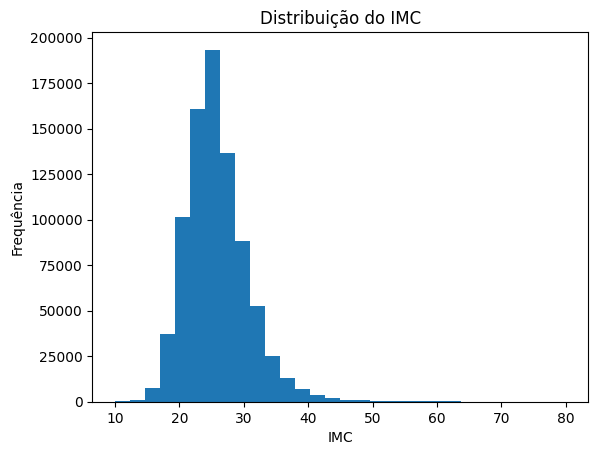

In [217]:
import matplotlib.pyplot as plt

plt.hist(obesidade_tratado['IMC'], bins=30)
plt.xlabel('IMC')
plt.ylabel('Frequência')
plt.title('Distribuição do IMC')
plt.show()

**Boxplot para detectar outliers**

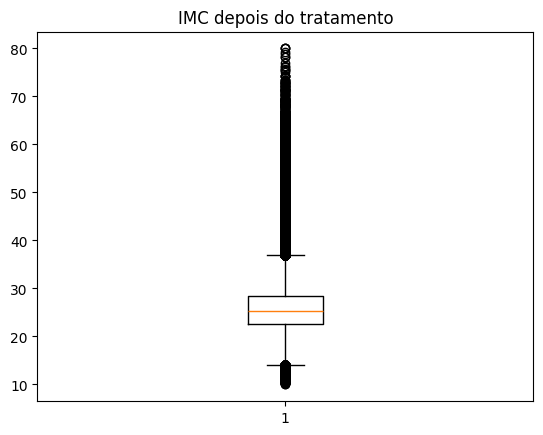

In [218]:
plt.boxplot(obesidade_tratado['IMC'].dropna())
plt.title('IMC depois do tratamento')
plt.show()

In [219]:
Q1 = obesidade_tratado['IMC'].quantile(0.25)
Q3 = obesidade_tratado['IMC'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = obesidade_tratado[(obesidade_tratado['IMC'] < lim_inf) | (obesidade_tratado['IMC'] > lim_sup)]

print(f'Total de outliers: {len(outliers)}')
print(f'lim_inf: {lim_inf:.2f}')
print(f'lim_sup: {lim_sup:.2f}')

Total de outliers: 21791
lim_inf: 14.08
lim_sup: 36.95


***Os valores identificados pelo método IQR como outliers não foram automaticamente removidos, pois valores elevados de IMC representam indivíduos com obesidade severa e possuem relevância epidemiológica. Foram removidos apenas valores biologicamente incompatíveis.***

In [220]:
resumo = pd.DataFrame({
    'Média': obesidade_tratado[['peso', 'altura', 'IMC']].mean(),
    'Mediana': obesidade_tratado[['peso', 'altura', 'IMC']].median(),
    'Desvio Padrão': obesidade_tratado[['peso', 'altura', 'IMC']].std(),
    'Mínimo': obesidade_tratado[['peso', 'altura', 'IMC']].min(),
    'Máximo': obesidade_tratado[['peso', 'altura', 'IMC']].max()
}).round(2)

print(resumo)

        Média  Mediana  Desvio Padrão  Mínimo  Máximo
peso    70.27    69.00          14.75    30.0   300.0
altura   1.65     1.65           0.10     1.2     2.2
IMC     25.86    25.34           4.88    10.0    80.0


## **3. Teste de hipótese (diferença de proporções)**

**Afirmação inicial: *a prevalência média de obesidade em Fortaleza é menor do que a prevalência média das demais capitais do Nordeste.*** 

**Hipótese:**

<div align="center">

$[H_0: p_F - p_{\text{outras capitais NE}} = 0 ]$

$[H_1: p_F - p_{\text{outras capitais NE}}< 0 ]$

**1. Criando uma variável categórica de obesidade**

<div align="center">

$IMC \geq 30 \rarr$  Obeso

In [221]:
capitais_ne = ['maceio', 'salvador', 'sao luis', 'joao pessoa', 'fortaleza', 'recife', 'teresina', 'natal', 'aracaju']

In [222]:
dados_ne = obesidade_tratado[
    obesidade_tratado['cidade'].isin(capitais_ne)
]

In [223]:
dados_ne['obeso'] = (
    dados_ne['IMC'] >= 30
).astype(int)

C:\Users\igorx\AppData\Local\Temp\ipykernel_15544\935613086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ne['obeso'] = (


**2. Separar Fortaleza e outras capitais**

In [224]:
fortaleza = dados_ne[
    dados_ne['cidade'] == 'fortaleza'
]

# Excluindo fortaleza dos dados
outras_ne = dados_ne[
    dados_ne['cidade'] != 'fortaleza'
]

print(f'tamanho fortaleza: {len(fortaleza)}')
print(f'tamanho outras_ne: {len(outras_ne)}')

tamanho fortaleza: 31152
tamanho outras_ne: 249091


**3. Cálculo do tamanho mínimo de amostra**